# Load Data

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
file_path = '/content/garch_dataset_400.xlsx'
df = pd.read_excel(file_path, parse_dates=['Date'], index_col='Date')

In [8]:
# Siapkan data return (didarab 100 untuk scaling GARCH)
returns = df['Return'] * 100
returns = returns.dropna()

# lihat 5 data terawal
print("5 Data Terawal:")
print(returns.head(), "\n")

5 Data Terawal:
Date
2022-01-03   -1.085631
2022-01-04    1.026311
2022-01-05    0.297559
2022-01-06   -1.579499
2022-01-07   -0.637602
Name: Return, dtype: float64 



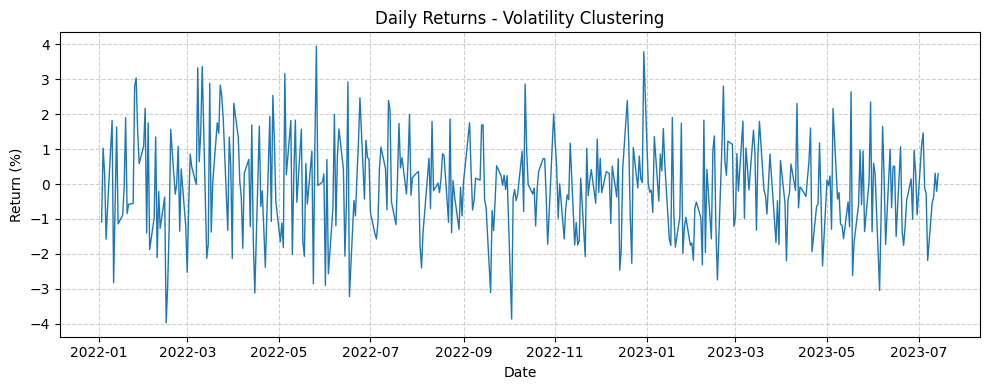

In [9]:
# Plot data untuk melihat volatility clustering
plt.figure(figsize=(10, 4))
plt.plot(returns, linewidth=1)
plt.title('Daily Returns - Volatility Clustering')
plt.xlabel('Date')
plt.ylabel('Return (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Uji Stasioneritas dan Efek ARCH

In [10]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch

In [13]:
print("--- Uji Stasioneritas (ADF Test) ---")
adf_test = adfuller(returns)

print(f"ADF Statistic : {adf_test[0]:.4f}")
print(f"p-value       : {adf_test[1]:.4f}")

--- Uji Stasioneritas (ADF Test) ---
ADF Statistic : -19.6391
p-value       : 0.0000


In [14]:
print("--- Uji Efek ARCH (Engle's ARCH Test) ---")
arch_test = het_arch(returns)

print(f"LM Statistic : {arch_test[0]:.4f}")
print(f"p-value      : {arch_test[1]:.4f}")

--- Uji Efek ARCH (Engle's ARCH Test) ---
LM Statistic : 14.3694
p-value      : 0.1568


# Model GARCH

In [4]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.3 MB/s eta 0:00:00


In [16]:
# !pip install arch
from arch import arch_model

# Mendefinisikan spesifikasi model
model = arch_model(returns, mean='Constant', vol='GARCH', p=1, q=1, dist='Normal')
print("model GARCH(1,1)")

model GARCH(1,1)


In [17]:
# Proses estimasi parameter (disp='off' menyembunyikan log iterasi)
results = model.fit(disp='off')

# Menampilkan tabel hasil
print(results.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -689.986
Distribution:                  Normal   AIC:                           1387.97
Method:            Maximum Likelihood   BIC:                           1403.94
                                        No. Observations:                  400
Date:                Fri, Apr 24 2026   Df Residuals:                      399
Time:                        06:56:09   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu            -0.0863  6.706e-02     -1.287      0.198 [ -0.218,

# Fitting Model

In [18]:
# Ekstraksi volatilitas kondisional dan sisaan (residual) model
cond_vol = results.conditional_volatility
std_resid = results.resid / cond_vol

# Menghapus nilai kosong jika ada
std_resid = std_resid.dropna()

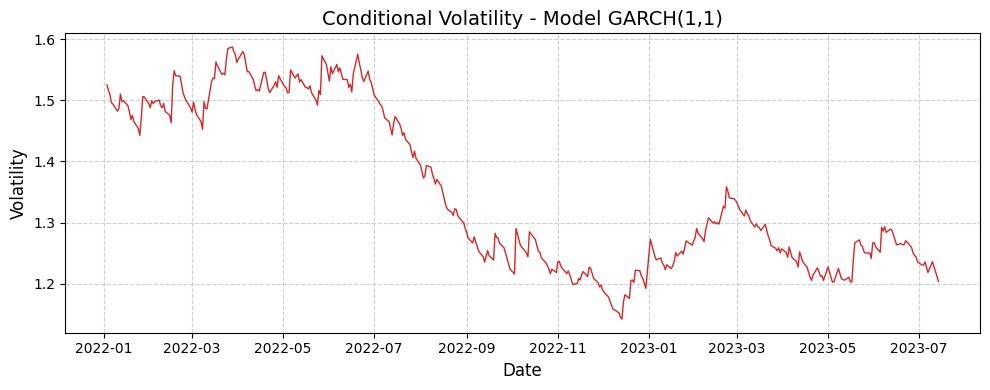

In [19]:
plt.figure(figsize=(10, 4))
plt.plot(cond_vol, color='#d62728', linewidth=1)
plt.title('Conditional Volatility - Model GARCH(1,1)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Volatility', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [20]:
print("--- Uji Ulang Efek ARCH (Evaluasi Residual) ---")
arch_test_resid = het_arch(std_resid)

print(f"LM Statistic : {arch_test_resid[0]:.4f}")
print(f"p-value      : {arch_test_resid[1]:.4f}")

--- Uji Ulang Efek ARCH (Evaluasi Residual) ---
LM Statistic : 7.2578
p-value      : 0.7009


In [28]:
import numpy as np
import pandas as pd

print("--- Prediksi Volatilitas (10 Hari Ke Depan) ---")

# 1. Melakukan prediksi dengan horizon 10 hari
forecasts = results.forecast(horizon=10)
future_variance = forecasts.variance.iloc[-1]
future_volatility = np.sqrt(future_variance)

# 2. Menentukan tanggal prediksi (10 hari bursa ke depan)
last_date = returns.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=10)
forecast_series = pd.Series(future_volatility.values, index=future_dates)

# Menampilkan hasil angka prediksi
print("Nilai Prediksi Volatilitas (%):")
for date, vol in forecast_series.items():
    print(f"{date.strftime('%Y-%m-%d')} : {vol:.4f}%")

--- Prediksi Volatilitas (10 Hari Ke Depan) ---
Nilai Prediksi Volatilitas (%):
2023-07-17 : 1.1964%
2023-07-18 : 1.1968%
2023-07-19 : 1.1973%
2023-07-20 : 1.1978%
2023-07-21 : 1.1982%
2023-07-24 : 1.1987%
2023-07-25 : 1.1992%
2023-07-26 : 1.1996%
2023-07-27 : 1.2001%
2023-07-28 : 1.2005%


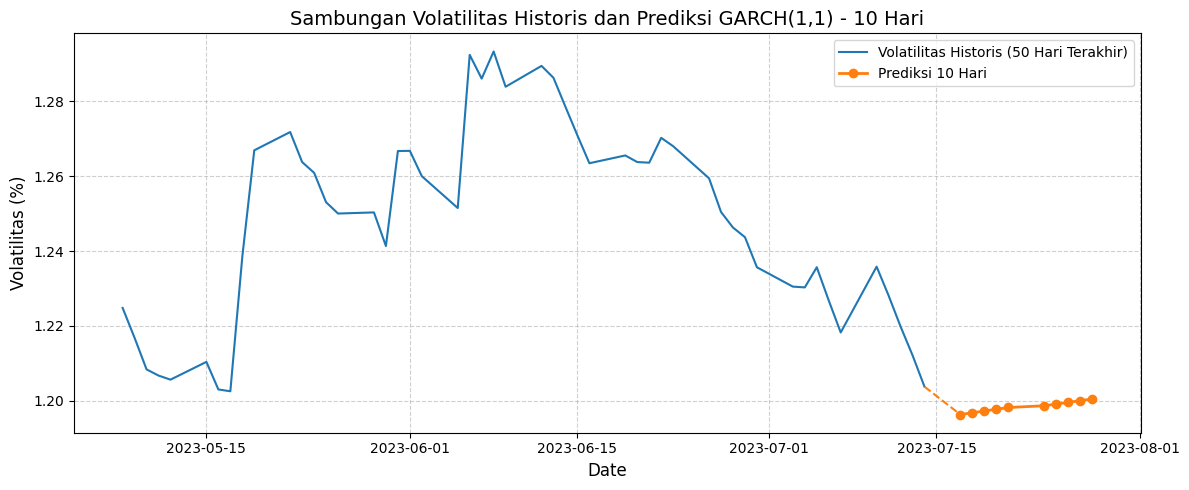

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# 1. Menyiapkan data 50 hari terakhir
cond_vol = results.conditional_volatility
recent_vol = cond_vol.tail(50)

# 2. Plot volatilitas historis (garis biru)
plt.plot(recent_vol.index, recent_vol.values, label='Volatilitas Historis (50 Hari Terakhir)', color='#1f77b4', linewidth=1.5)

# 3. Membuat garis putus-putus untuk menyambung titik terakhir historis ke titik pertama prediksi
plt.plot([recent_vol.index[-1], forecast_series.index[0]],
         [recent_vol.values[-1], forecast_series.values[0]],
         color='#ff7f0e', linestyle='--', linewidth=1.5)

# 4. Plot prediksi volatilitas (garis oranye dengan penanda titik)
plt.plot(forecast_series.index, forecast_series.values, label='Prediksi 10 Hari', color='#ff7f0e', marker='o', linewidth=2)

# Konfigurasi tampilan grafik
plt.title('Sambungan Volatilitas Historis dan Prediksi GARCH(1,1) - 10 Hari', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Volatilitas (%)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Evaluasi dan Diagnostik Residual

In [30]:
# Ekstraksi volatilitas kondisional dan sisaan (residual) model
cond_vol = results.conditional_volatility
std_resid = results.resid / cond_vol

# Menghapus nilai kosong jika ada
std_resid = std_resid.dropna()
print("Standardized residuals berhasil diekstrak.")

Standardized residuals berhasil diekstrak.


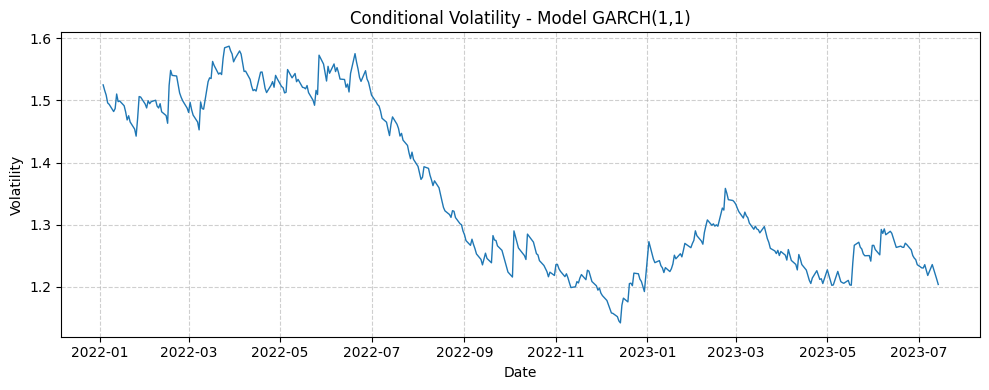

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(cond_vol, linewidth=1)
plt.title('Conditional Volatility - Model GARCH(1,1)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [32]:
from statsmodels.stats.diagnostic import het_arch

print("Uji Ulang Efek ARCH (Evaluasi Residual)")
arch_test_resid = het_arch(std_resid)

print(f"LM Statistic : {arch_test_resid[0]:.4f}")
print(f"p-value      : {arch_test_resid[1]:.4f}")

--- Uji Ulang Efek ARCH (Evaluasi Residual) ---
LM Statistic : 7.2578
p-value      : 0.7009
